# 03 — Communication Sentiment Analysis (VADER)

> **Purpose:** Detailed evaluation of internal agent-to-agent communication sentiment across the 70 experiment runs using rule-based VADER sentiment analysis.
> 
> **Core DVs Analyzed:**
> - Compound sentiment score per message ($-1.0$ to $+1.0$)
> - Boss vs. Worker message sentiment gap
> - Per-phase average sentiment dynamics (tone shift during Review/Revision phases 5–6)
> - Aggregate run-level compound sentiment scores for cross-style comparison
> - Sentiment trajectories over conversation sequence turns


## §0 — Setup & Data Loading

Import required libraries, load all `sentiment.json` logs across the 70 experiment runs, and construct message-level and run-level DataFrames.


In [1]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set visual style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.titlesize'] = 14

STYLE_COLORS = {
    'coercive': '#d62728',       # Red
    'authoritative': '#ff7f0e',  # Orange
    'affiliative': '#2ca02c',    # Green
    'democratic': '#1f77b4',     # Blue
    'pacesetting': '#9467bd',    # Purple
    'coaching': '#bcbd22',       # Yellow-green
    'baseline': '#7f7f7f'        # Gray
}

STYLE_ORDER = ['coercive', 'authoritative', 'affiliative', 'democratic', 'pacesetting', 'coaching', 'baseline']

# Hardcoded results path in MAS
RESULTS_DIR = '/Users/hellligkeit/Documents/FS/Masterthesis/MAS/results'

run_dirs = sorted([
    os.path.join(RESULTS_DIR, d)
    for d in os.listdir(RESULTS_DIR)
    if os.path.isdir(os.path.join(RESULTS_DIR, d)) and '_run' in d
])

print(f'Resolved RESULTS_DIR: {os.path.abspath(RESULTS_DIR)}')
print(f'Found {len(run_dirs)} total run directories in results/')

# Load all sentiment.json files into message-level and run-level DataFrames
all_messages = []
all_runs = []

for run_dir in run_dirs:
    sentiment_file = os.path.join(run_dir, 'sentiment.json')
    if not os.path.exists(sentiment_file):
        continue
    try:
        with open(sentiment_file, 'r', encoding='utf-8') as f:
            data = json.load(f)
    except Exception as e:
        print(f'Skipped {os.path.basename(run_dir)}: {e}')
        continue

    if not data.get('valid', False):
        continue

    dirname = os.path.basename(run_dir)
    parts = dirname.split('_')
    if len(parts) < 3:
        continue
    style = parts[0]
    task = parts[1]
    run_id = parts[2].replace('run', '')

    agg = data.get('aggregates', {})
    per_agent = agg.get('per_agent', {})
    run_agg = agg.get('run', {})
    boss_vs = agg.get('boss_vs_workers', {})

    for msg in data.get('messages', []):
        all_messages.append({
            'seq': msg.get('seq'),
            'sender': msg.get('sender'),
            'phase': msg.get('phase'),
            'compound': msg.get('compound'),
            'positive': msg.get('positive'),
            'negative': msg.get('negative'),
            'neutral': msg.get('neutral'),
            'style': style,
            'task': task,
            'run_id': run_id,
            'run_dir': dirname,
        })

    all_runs.append({
        'style': style,
        'task': task,
        'run_id': run_id,
        'run_dir': dirname,
        'run_mean_compound': run_agg.get('mean_compound'),
        'boss_mean_compound': per_agent.get('Boss', {}).get('mean_compound'),
        'worker_mean_compound': boss_vs.get('worker_mean'),
        'boss_worker_gap': boss_vs.get('gap'),
    })

df_msg_sent = pd.DataFrame(all_messages)
df_run_sent = pd.DataFrame(all_runs)

# Enforce consistent categorical ordering
if not df_msg_sent.empty:
    df_msg_sent['style'] = pd.Categorical(df_msg_sent['style'], categories=STYLE_ORDER, ordered=True)
    df_msg_sent['phase'] = pd.to_numeric(df_msg_sent['phase'], errors='coerce')
if not df_run_sent.empty:
    df_run_sent['style'] = pd.Categorical(df_run_sent['style'], categories=STYLE_ORDER, ordered=True)

print(f'Loaded {len(df_msg_sent)} messages from {len(df_run_sent)} runs')
print(df_run_sent.head())

Resolved RESULTS_DIR: /Users/hellligkeit/Documents/FS/Masterthesis/MAS/results
Found 70 total run directories in results/
Loaded 1033 messages from 70 runs
         style  task run_id                 run_dir  run_mean_compound  \
0  affiliative  long     01  affiliative_long_run01             0.9703   
1  affiliative  long     02  affiliative_long_run02             0.9779   
2  affiliative  long     03  affiliative_long_run03             0.9601   
3  affiliative  long     04  affiliative_long_run04             0.9656   
4  affiliative  long     05  affiliative_long_run05             0.9364   

   boss_mean_compound  worker_mean_compound  boss_worker_gap  
0              0.9778                0.9628           0.0150  
1              0.9890                0.9682           0.0209  
2              0.9830                0.9372           0.0457  
3              0.9913                0.9398           0.0515  
4              0.9907                0.8820           0.1087  


## §1 — Overall Communication Sentiment by Leadership Style

Analyze average VADER compound scores across leadership styles and task complexities.


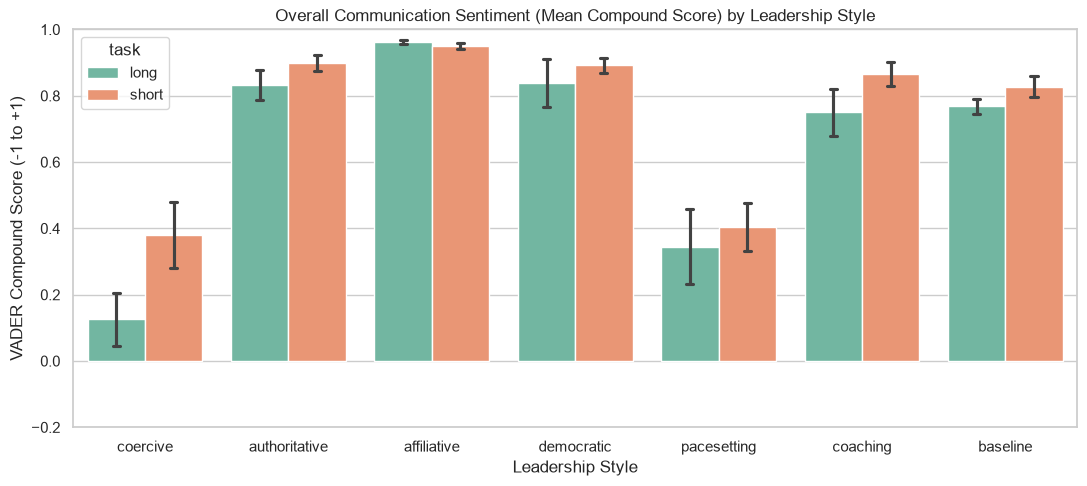

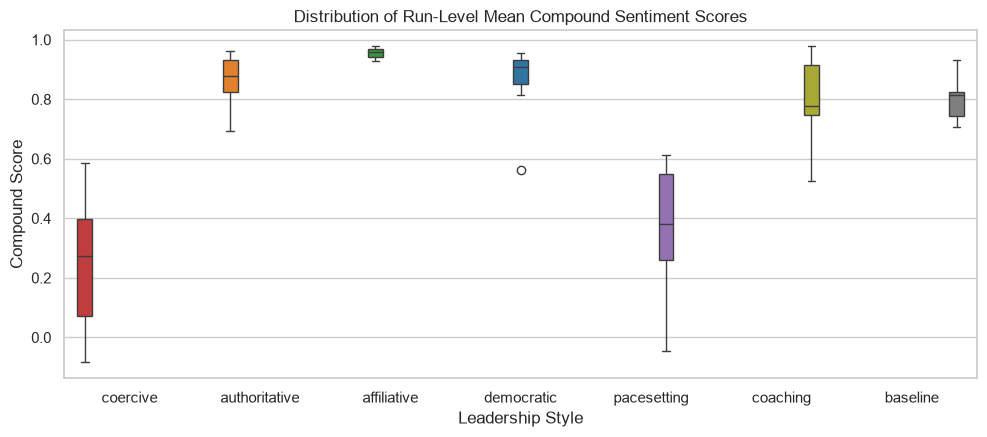

In [2]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=df_run_sent, x='style', y='run_mean_compound', hue='task', 
    palette='Set2', order=STYLE_ORDER, errorbar='se', capsize=0.1, ax=ax
)
ax.set_title('Overall Communication Sentiment (Mean Compound Score) by Leadership Style')
ax.set_ylabel('VADER Compound Score (-1 to +1)')
ax.set_xlabel('Leadership Style')
ax.set_ylim(-0.2, 1.0)
plt.tight_layout()
plt.show()

# Boxplot distribution
plt.figure(figsize=(10, 4.5))
sns.boxplot(data=df_run_sent, x='style', y='run_mean_compound', hue='style', palette=STYLE_COLORS, order=STYLE_ORDER, legend=False)
plt.title('Distribution of Run-Level Mean Compound Sentiment Scores')
plt.ylabel('Compound Score')
plt.xlabel('Leadership Style')
plt.tight_layout()
plt.show()


## §2 — Boss vs. Worker Sentiment Gap

Compare the tone of the Boss against team workers (Coder, Writer, Reviewer) across leadership styles.


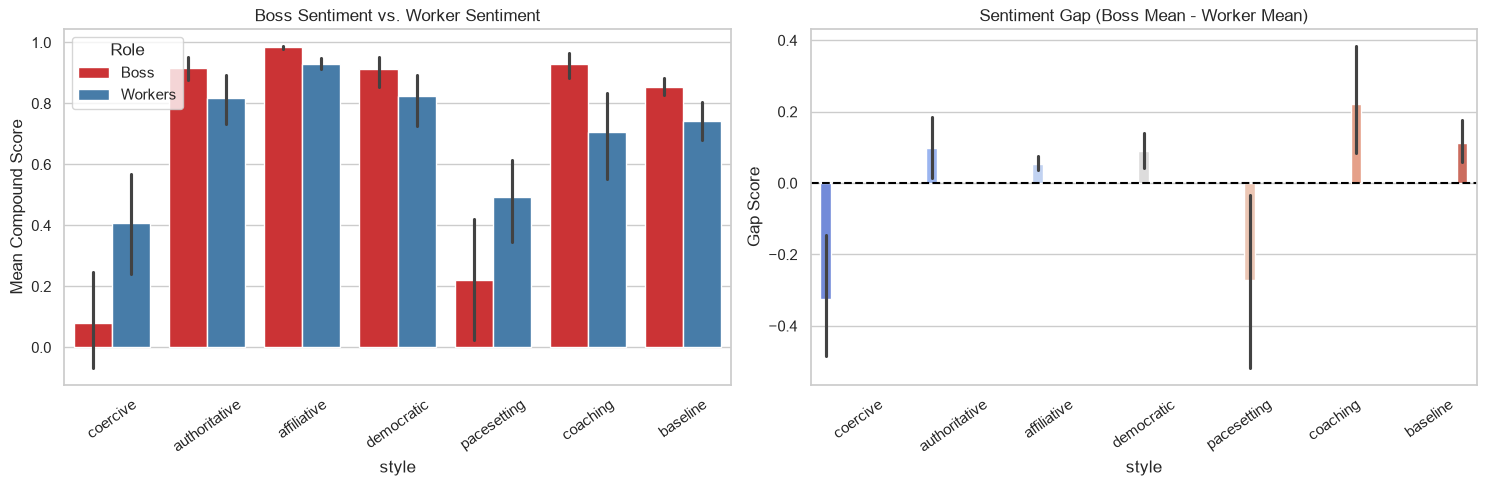

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boss vs Worker Mean
df_melted = df_run_sent.melt(id_vars=['style', 'task'], value_vars=['boss_mean_compound', 'worker_mean_compound'], var_name='Role', value_name='Compound')
df_melted['Role'] = df_melted['Role'].map({'boss_mean_compound': 'Boss', 'worker_mean_compound': 'Workers'})

sns.barplot(data=df_melted, x='style', y='Compound', hue='Role', palette='Set1', order=STYLE_ORDER, ax=axes[0])
axes[0].set_title('Boss Sentiment vs. Worker Sentiment')
axes[0].set_ylabel('Mean Compound Score')
axes[0].tick_params(axis='x', rotation=35)

# Gap
sns.barplot(data=df_run_sent, x='style', y='boss_worker_gap', hue='style', palette='coolwarm', order=STYLE_ORDER, legend=False, ax=axes[1])
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('Sentiment Gap (Boss Mean - Worker Mean)')
axes[1].set_ylabel('Gap Score')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()


## §3 — Phase-Level Sentiment Dynamics (Tone Shift)

Track how communication sentiment evolves across the 6 main workflow phases (Briefing, Planning, Coding, Writing, Review, Revision).


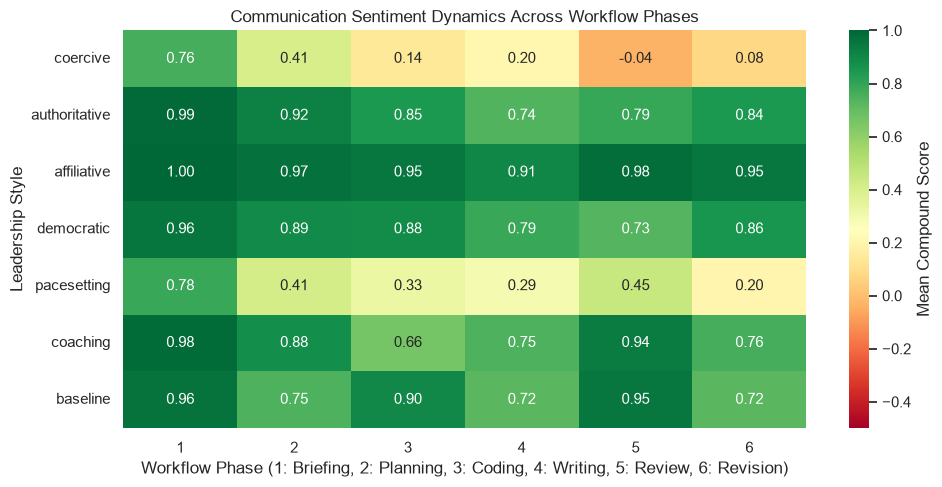

In [4]:
df_msg_valid = df_msg_sent[df_msg_sent['phase'].notnull()].copy()
df_msg_valid['phase'] = pd.Categorical(
    df_msg_valid['phase'].astype(int),
    categories=[1, 2, 3, 4, 5, 6],
    ordered=True
)

phase_heatmap = df_msg_valid.groupby(['style', 'phase'], observed=True)['compound'].mean().unstack()
phase_heatmap = phase_heatmap.reindex(STYLE_ORDER)

plt.figure(figsize=(10, 5))
sns.heatmap(
    phase_heatmap,
    annot=True,
    cmap='RdYlGn',
    fmt='.2f',
    vmin=-0.5,
    vmax=1.0,
    cbar_kws={'label': 'Mean Compound Score'}
)
plt.title('Communication Sentiment Dynamics Across Workflow Phases')
plt.xlabel('Workflow Phase (1: Briefing, 2: Planning, 3: Coding, 4: Writing, 5: Review, 6: Revision)')
plt.ylabel('Leadership Style')
plt.tight_layout()
plt.show()

## §4 — Per-Agent Sentiment Breakdown

Examine the individual sentiment profiles of the Boss, Coder, Writer, and Reviewer.


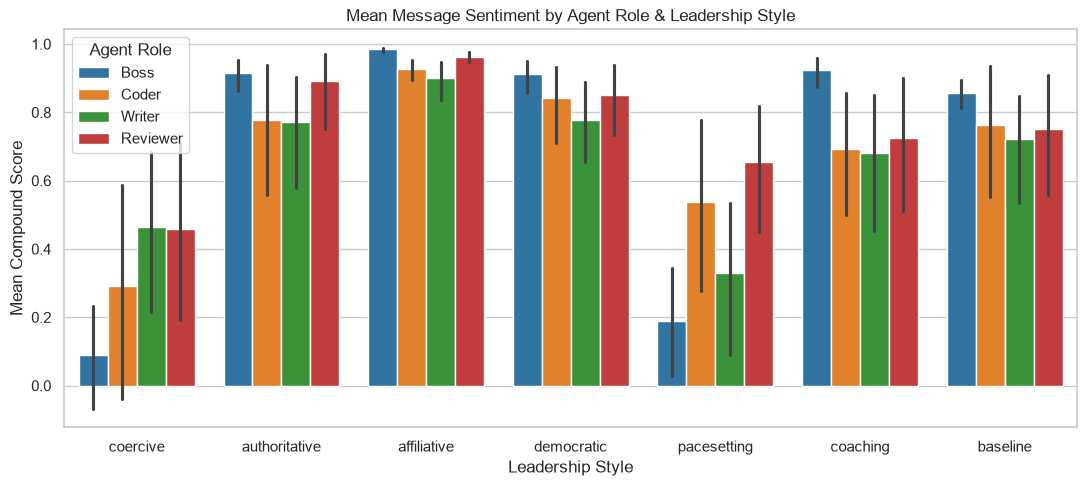

In [5]:
plt.figure(figsize=(11, 5))
sns.barplot(data=df_msg_sent, x='style', y='compound', hue='sender', palette='tab10', order=STYLE_ORDER)
plt.title('Mean Message Sentiment by Agent Role & Leadership Style')
plt.ylabel('Mean Compound Score')
plt.xlabel('Leadership Style')
plt.legend(title='Agent Role')
plt.tight_layout()
plt.show()


## §5 — Non-Parametric Statistical Testing on Sentiment Metrics

Perform Kruskal-Wallis tests to assess statistically significant differences in communication sentiment across styles.


In [6]:
groups_run = [g['run_mean_compound'].dropna().values for _, g in df_run_sent.groupby('style')]
H_run, p_run = stats.kruskal(*groups_run)

groups_gap = [g['boss_worker_gap'].dropna().values for _, g in df_run_sent.groupby('style')]
H_gap, p_gap = stats.kruskal(*groups_gap)

stats_sent = pd.DataFrame([
    {'Metric': 'Overall Run Mean Compound', 'H-Statistic': round(H_run, 3), 'p-value': round(p_run, 4), 'Significant (p < .05)': 'Yes' if p_run < 0.05 else 'No'},
    {'Metric': 'Boss-Worker Sentiment Gap', 'H-Statistic': round(H_gap, 3), 'p-value': round(p_gap, 4), 'Significant (p < .05)': 'Yes' if p_gap < 0.05 else 'No'}
])

print("="*65)
print("     KRUSKAL-WALLIS STATISTICAL TESTS FOR VADER SENTIMENT")
print("="*65)
print(stats_sent.to_string(index=False))


     KRUSKAL-WALLIS STATISTICAL TESTS FOR VADER SENTIMENT
                   Metric  H-Statistic  p-value Significant (p < .05)
Overall Run Mean Compound       51.198   0.0000                   Yes
Boss-Worker Sentiment Gap       19.859   0.0029                   Yes


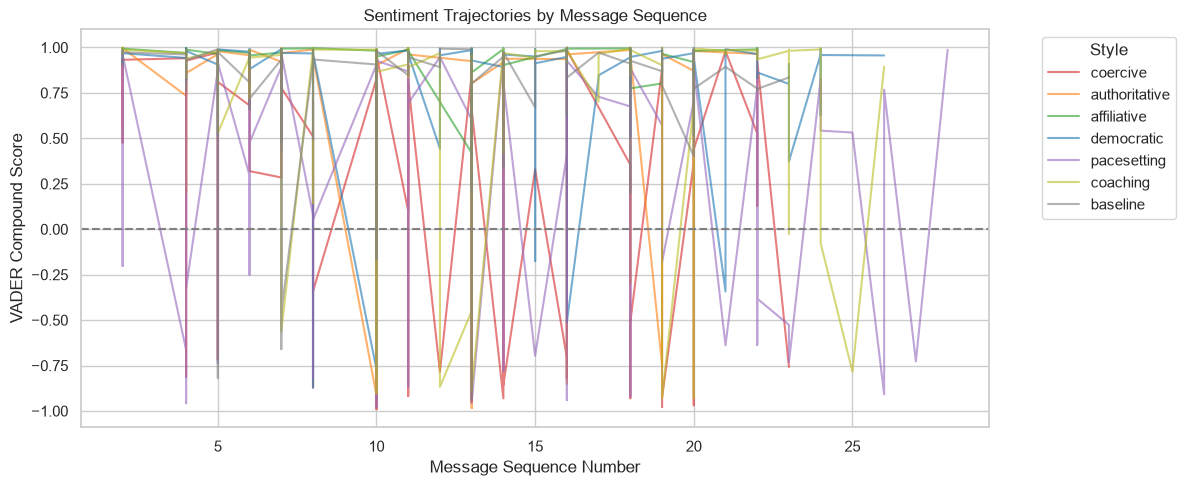

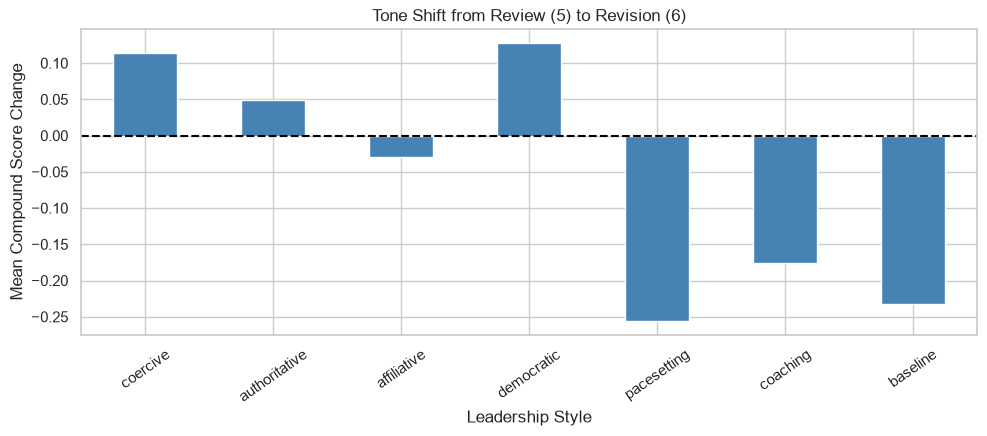

In [7]:
# Sentiment trajectories over conversation turns
fig, ax = plt.subplots(figsize=(12, 5))
for style in STYLE_ORDER:
    style_msgs = df_msg_sent[df_msg_sent['style'] == style].sort_values('seq')
    if not style_msgs.empty:
        ax.plot(style_msgs['seq'], style_msgs['compound'], label=style, color=STYLE_COLORS[style], alpha=0.6)
ax.axhline(0, color='gray', linestyle='--')
ax.set_title('Sentiment Trajectories by Message Sequence')
ax.set_xlabel('Message Sequence Number')
ax.set_ylabel('VADER Compound Score')
ax.legend(title='Style', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Tone shift between Review (phase 5) and Revision (phase 6)
phase_56 = df_msg_sent[df_msg_sent['phase'].isin([5, 6])].copy()
if not phase_56.empty:
    phase_56['phase'] = pd.Categorical(phase_56['phase'].astype(int), categories=[5, 6], ordered=True)
    phase_shift = phase_56.groupby(['style', 'phase'], observed=True)['compound'].mean().unstack()
    phase_shift = phase_shift.reindex(STYLE_ORDER)
    phase_shift['tone_shift'] = phase_shift[6] - phase_shift[5]

    fig, ax = plt.subplots(figsize=(10, 4.5))
    phase_shift['tone_shift'].plot(kind='bar', ax=ax, color='steelblue')
    ax.axhline(0, color='black', linestyle='--')
    ax.set_title('Tone Shift from Review (5) to Revision (6)')
    ax.set_ylabel('Mean Compound Score Change')
    ax.set_xlabel('Leadership Style')
    ax.tick_params(axis='x', rotation=35)
    plt.tight_layout()
    plt.show()